In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Caricamento dati
wine = load_wine()
print(wine)

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

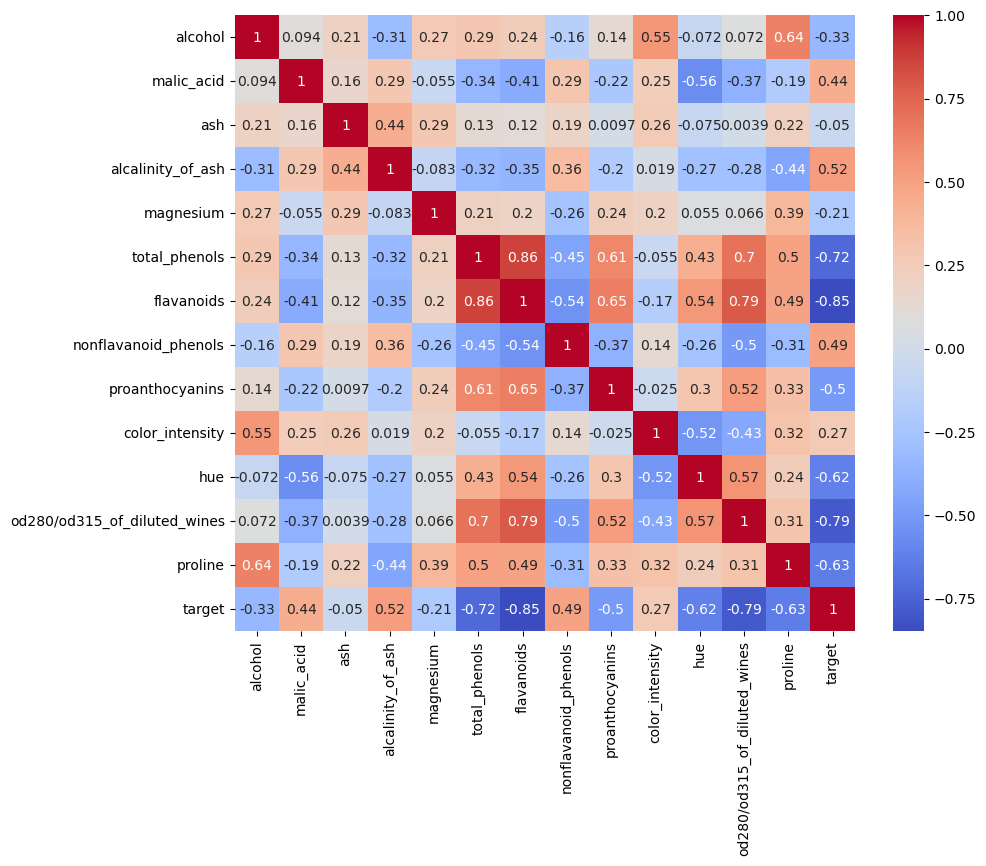

In [31]:
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

df1 = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df1['target'] = wine.target

df1 = df1.drop(columns=['total_phenols'])  # Rimuoviamo la colonna 'total_phenols' da df1

columns = df.columns.tolist()[:-1]  # Escludiamo la colonna 'target'
#print(df['target'])

columns = df1.columns.tolist()[:-1]  # Escludiamo la colonna 'target'
#print(df['target']

df.head()
df.info()
df.describe()

print(df.isnull().sum())
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

Lavoro su tutte le features

In [32]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1) Load data
X, y = load_wine(return_X_y=True)


# 2) Train/Test split (test set held out and used ONLY at the end)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,          # keep class proportions
    random_state=42
)

# 3) Pipeline: scaling + KNN (prevents data leakage in CV)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# 4) Hyperparameter grid to search (k, weighting, distance)
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

# 5) Cross-validation ONLY on the training set
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 6) Grid search (find best hyperparameters on train via CV)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,        # after CV, refit best model on ALL X_train
    return_train_score=True
)

gs.fit(X_train, y_train)

print("Best params (from CV on train):", gs.best_params_)
print("Best CV accuracy (mean over folds):", gs.best_score_)

# 7) Best model already refit on the entire training set
best_model = gs.best_estimator_

# 8) Final evaluation on the held-out test set (unbiased estimate)
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", test_acc)

test_pre = precision_score(y_test, y_pred, average="macro")
print("\nTest precision:", test_pre)

test_rec = recall_score(y_test, y_pred, average="macro")
print("\nTest recall:", test_rec)

test_f1  = f1_score(y_test, y_pred, average="macro")
print("\nTest f1:", test_f1)

Best params (from CV on train): {'knn__n_neighbors': 4, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV accuracy (mean over folds): 0.990909090909091

Test accuracy: 0.9722222222222222

Test precision: 0.9743589743589745

Test recall: 0.9770114942528735

Test f1: 0.9747619047619048


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="saga", max_iter=5000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", test_acc)

test_pre = precision_score(y_test, y_pred, average="macro")
print("\nTest precision:", test_pre)

test_rec = recall_score(y_test, y_pred, average="macro")
print("\nTest recall:", test_rec)

test_f1  = f1_score(y_test, y_pred, average="macro")
print("\nTest f1:", test_f1)


Test accuracy: 0.9722222222222222

Test precision: 0.9743589743589745

Test recall: 0.9770114942528735

Test f1: 0.9747619047619048


Tutte le feature meno quella feature

In [ ]:
target_col = "target"   # <-- cambia con il nome della tua colonna target

X = df1.drop(columns=[target_col]).to_numpy()
y = df1[target_col].to_numpy()

# 2) Train/Test split (test set held out and used ONLY at the end)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,          # keep class proportions
    random_state=42
)

# 3) Pipeline: scaling + KNN (prevents data leakage in CV)
pipeknn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# 4) Hyperparameter grid to search (k, weighting, distance)
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

# 5) Cross-validation ONLY on the training set
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 6) Grid search (find best hyperparameters on train via CV)
gs = GridSearchCV(
    estimator=pipeknn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,        # after CV, refit best model on ALL X_train
    return_train_score=True
)

gs.fit(X_train, y_train)

print("Best params (from CV on train):", gs.best_params_)
print("Best CV accuracy (mean over folds):", gs.best_score_)

# 7) Best model already refit on the entire training set
best_model1 = gs.best_estimator_

# 8) Final evaluation on the held-out test set (unbiased estimate)
y_pred = best_model1.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", test_acc)

test_pre = precision_score(y_test, y_pred, average="macro")
print("\nTest precision:", test_pre)

test_rec = recall_score(y_test, y_pred, average="macro")
print("\nTest recall:", test_rec)

test_f1  = f1_score(y_test, y_pred, average="macro")
print("\nTest f1:", test_f1)

Best params (from CV on train): {'knn__n_neighbors': 6, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV accuracy (mean over folds): 0.990909090909091

Test accuracy: 0.9722222222222222

Test precision: 0.9743589743589745

Test recall: 0.9770114942528735

Test f1: 0.9747619047619048


In [ ]:
pipe1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="saga", max_iter=5000, random_state=42))
])

pipe1.fit(X_train, y_train)
y_pred = pipe1.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", test_acc)

test_pre = precision_score(y_test, y_pred, average="macro")
print("\nTest precision:", test_pre)

test_rec = recall_score(y_test, y_pred, average="macro")
print("\nTest recall:", test_rec)

test_f1  = f1_score(y_test, y_pred, average="macro")
print("\nTest f1:", test_f1)


Test accuracy: 1.0

Test precision: 1.0

Test recall: 1.0

Test f1: 1.0


In [34]:

import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/knn_model_pipe.joblib")
joblib.dump(pipe, "models/mlr_model_pipe.joblib")
joblib.dump(columns, "models/columns.joblib")

['models/columns.joblib']